# Plotting a graph over time of the affilitions

In [35]:
import pandas as pd
import numpy as np
All_Data = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/5. Final consolidation of all data/5.A. Data created in 5./5.2./Final affiliations.xlsx') 
print(All_Data.shape)

(22790, 40)


In [36]:
All_Data.rename(columns = {'Year':'year'}, inplace = True)

All_Data = All_Data.replace('University Of Wisconsin-Madison', 'University Of Wisconsin')

melted = All_Data.melt(id_vars= ['Article_ID','year'], value_vars=['0_Auth_affs_0', '0_Auth_affs_1', '0_Auth_affs_2', '0_Auth_affs_3', '0_Auth_affs_4', 
                                '1_Auth_affs_0' , '1_Auth_affs_1', '1_Auth_affs_2', '1_Auth_affs_3', '1_Auth_affs_4',
                                '2_Auth_affs_0', '2_Auth_affs_1', '2_Auth_affs_2', '2_Auth_affs_3', '2_Auth_affs_4',
                                '3_Auth_affs_0', '3_Auth_affs_1', '3_Auth_affs_2', '3_Auth_affs_3', '3_Auth_affs_4',
                                '4_Auth_affs_0', '4_Auth_affs_1', '4_Auth_affs_2' , '4_Auth_affs_3',
                                '5_Auth_affs_0',
                                '6_Auth_affs_0','7_Auth_affs_0']).dropna()

melted.rename(columns = {'variable':'Aff number'}, inplace = True)
melted.rename(columns = {'value':'Affiliation'}, inplace = True)

melted = melted.sort_values(by=['year'])

#print(melted.head())
print(melted.shape)

melted['aff_cum_sum'] = melted.groupby(['Affiliation']).cumcount()+1

melted['Weight'] = 1
melted = melted[['Article_ID' ,'Weight', 'Affiliation','year',]]
melted.tail()

melted_master_condenced = melted.copy()
melted_master_condenced.head()


(37804, 4)


,Article_ID,Weight,Affiliation,year
0,2967475,1,Cambridge Massachusetts United States (City),1940
18582,1807581,1,Queens College,1940
18581,1807580,1,University Of Wisconsin,1940
18580,1807579,1,University Of North Carolina,1940
18579,1807578,1,Brookings Institution,1940


In [37]:
melted_master_condenced['decade'] = ''
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1940) & (melted_master_condenced['year'] < 1950), '[1940,1949]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1950) & (melted_master_condenced['year'] < 1960), '[1950,1959]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1960) & (melted_master_condenced['year'] < 1970), '[1960,1969]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1970) & (melted_master_condenced['year'] < 1980), '[1970,1979]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1980) & (melted_master_condenced['year'] < 1990), '[1980,1989]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1990) & (melted_master_condenced['year'] < 2000), '[1990,1999]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2000) & (melted_master_condenced['year'] < 2011), '[2000,2010]', melted_master_condenced['decade'])
print(melted_master_condenced.head())
print(melted_master_condenced.tail())

       Article_ID  Weight                                   Affiliation  year  \
0         2967475       1  Cambridge Massachusetts United States (City)  1940   
18582     1807581       1                                Queens College  1940   
18581     1807580       1                       University Of Wisconsin  1940   
18580     1807579       1                  University Of North Carolina  1940   
18579     1807578       1                         Brookings Institution  1940   

            decade  
0      [1940,1949]  
18582  [1940,1949]  
18581  [1940,1949]  
18580  [1940,1949]  
18579  [1940,1949]  
        Article_ID  Weight                                     Affiliation  \
237387    27805040       1                           University Of Chicago   
237386    27805039       1                            Stockholm University   
237383    27805036       1  London School Of Economics & Political Science   
237403    27805056       1                             Stanford University 

# Ranking the Universities based on their number of papers per published per decade

In [38]:


melted_master_condenced = melted_master_condenced.replace(['National Bureau Of Economic Research', 'Centre For Economic Policy Research (Cepr, England)','Canadian Institute For Advanced Research (Cifar)','Centre For Operations Research And Econometrics (Core, France)','National Institute Of Economic And Social Research, London','None'],"")
melted_master_condenced = melted_master_condenced.reset_index(drop=True)

#Gets the top 10 overall
melted_master_condenced = melted_master_condenced.sort_values(by=['year'])
melted_master_condenced['aff_cum_sum'] = melted_master_condenced.groupby(['Affiliation'])['Weight'].cumsum()

highest_vals = melted_master_condenced.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(50,'aff_cum_sum')
print(highest_vals_10.shape)
#print(highest_vals_10.head())
print(highest_vals_10.iat[6,2])

melted_master_condenced_decade = melted_master_condenced[['Article_ID','Weight','Affiliation','decade']]

a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.head())
print(a.shape)

(50, 6)
Yale University
       Article_ID  Weight      Affiliation       decade  aff_cum_counts_yearly
1949      1831743       1  Yale University  [1940,1949]                     53
4183      1816148       1  Yale University  [1950,1959]                     68
7408      1813212       1  Yale University  [1960,1969]                    129
13479     1914016       1  Yale University  [1970,1979]                    142
20398     1913625       1  Yale University  [1980,1989]                    168
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/442821731.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [39]:
a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[0,2]]
a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
#print(a['Affiliation'])

b = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[1,2]]
b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
b = b.drop_duplicates(subset = ['decade'], keep = 'last')
#print(b['Affiliation'])

c = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[2,2]]
c['aff_cum_sum_decade'] = c.groupby(['Affiliation','decade'])['Weight'].cumsum()
c = c.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[3,2]]
d['aff_cum_sum_decade'] = d.groupby(['Affiliation','decade'])['Weight'].cumsum()
d = d.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[4,2]]
e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()
e = e.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[5,2]]
f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
f = f.drop_duplicates(subset = ['decade'], keep = 'last')
print(f.shape)

g = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
g = g.drop_duplicates(subset = ['decade'], keep = 'last')
print(g.shape)

h = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[7,2]]
h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
h = h.drop_duplicates(subset = ['decade'], keep = 'last')
print(h.shape)

i = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[8,2]]
i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
i = i.drop_duplicates(subset = ['decade'], keep = 'last')
print(i.shape)

j = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[9,2]]
j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()
j = j.drop_duplicates(subset = ['decade'], keep = 'last')
print(j.shape)

k = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[10,2]]
k['aff_cum_sum_decade'] = k.groupby(['Affiliation','decade'])['Weight'].cumsum()
k = k.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[11,2]]
l['aff_cum_sum_decade'] = l.groupby(['Affiliation','decade'])['Weight'].cumsum()
l = l.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[12,2]]
m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
m = m.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[13,2]]
n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
n = n.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[14,2]]
o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
o = o.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[15,2]]
p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
p = p.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[16,2]]
q['aff_cum_sum_decade'] = q.groupby(['Affiliation','decade'])['Weight'].cumsum()
q = q.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[17,2]]
r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
r = r.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[18,2]]
s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
s = s.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[19,2]]
t['aff_cum_sum_decade'] = t.groupby(['Affiliation','decade'])['Weight'].cumsum()
t = t.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[20,2]]
u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
u = u.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[21,2]]
v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
v = v.drop_duplicates(subset = ['decade'], keep = 'last')
print(v.shape)

w = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[22,2]]
w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()
w = w.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[23,2]]
x['aff_cum_sum_decade'] = x.groupby(['Affiliation','decade'])['Weight'].cumsum()
x = x.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)

y = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[24,2]]
y['aff_cum_sum_decade'] = y.groupby(['Affiliation','decade'])['Weight'].cumsum()
y = y.drop_duplicates(subset = ['decade'], keep = 'last')
print(y.shape)

z = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[25,2]]
z['aff_cum_sum_decade'] = z.groupby(['Affiliation','decade'])['Weight'].cumsum()
z = z.drop_duplicates(subset = ['decade'], keep = 'last')
print(z.shape)

a1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[26,2]]
a1['aff_cum_sum_decade'] = a1.groupby(['Affiliation','decade'])['Weight'].cumsum()
a1= a1.drop_duplicates(subset = ['decade'], keep = 'last')
print(a1.shape)
print(a1['Affiliation'])

b1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[27,2]]
b1['aff_cum_sum_decade'] = b1.groupby(['Affiliation','decade'])['Weight'].cumsum()
b1 = b1.drop_duplicates(subset = ['decade'], keep = 'last')
print(b1.shape)
print(b1['Affiliation'])

c1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[28,2]]
c1['aff_cum_sum_decade'] = c1.groupby(['Affiliation','decade'])['Weight'].cumsum()
c1 = c1.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d1= melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[29,2]]
d1['aff_cum_sum_decade'] = d1.groupby(['Affiliation','decade'])['Weight'].cumsum()
d1 = d1.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[30,2]]
e1['aff_cum_sum_decade'] = e1.groupby(['Affiliation','decade'])['Weight'].cumsum()
e1 = e1.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[31,2]]
f1['aff_cum_sum_decade'] = f1.groupby(['Affiliation','decade'])['Weight'].cumsum()
f1 = f1.drop_duplicates(subset = ['decade'], keep = 'last')

g1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[32,2]]
g1['aff_cum_sum_decade'] = g1.groupby(['Affiliation','decade'])['Weight'].cumsum()
g1 = g1.drop_duplicates(subset = ['decade'], keep = 'last')

h1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[33,2]]
h1['aff_cum_sum_decade'] = h1.groupby(['Affiliation','decade'])['Weight'].cumsum()
h1 = h1.drop_duplicates(subset = ['decade'], keep = 'last')

i1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[34,2]]
i1['aff_cum_sum_decade'] = i1.groupby(['Affiliation','decade'])['Weight'].cumsum()
i1= i1.drop_duplicates(subset = ['decade'], keep = 'last')

j1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[35,2]]
j1['aff_cum_sum_decade'] = j1.groupby(['Affiliation','decade'])['Weight'].cumsum()
j1 = j1.drop_duplicates(subset = ['decade'], keep = 'last')

k1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[36,2]]
k1['aff_cum_sum_decade'] = k1.groupby(['Affiliation','decade'])['Weight'].cumsum()
k1 = k1.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[37,2]]
l1['aff_cum_sum_decade'] = l1.groupby(['Affiliation','decade'])['Weight'].cumsum()
l1 = l1.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[38,2]]
m1['aff_cum_sum_decade'] = m1.groupby(['Affiliation','decade'])['Weight'].cumsum()
m1 = m1.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[39,2]]
n1['aff_cum_sum_decade'] = n1.groupby(['Affiliation','decade'])['Weight'].cumsum()
n1 = n1.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[40,2]]
o1['aff_cum_sum_decade'] = o1.groupby(['Affiliation','decade'])['Weight'].cumsum()
o1 = o1.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p1= melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[41,2]]
p1['aff_cum_sum_decade'] = p1.groupby(['Affiliation','decade'])['Weight'].cumsum()
p1 = p1.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[42,2]]
q1['aff_cum_sum_decade'] = q1.groupby(['Affiliation','decade'])['Weight'].cumsum()
q1 = q1.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[43,2]]
r1['aff_cum_sum_decade'] = r1.groupby(['Affiliation','decade'])['Weight'].cumsum()
r1 = r1.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[44,2]]
s1['aff_cum_sum_decade'] = s1.groupby(['Affiliation','decade'])['Weight'].cumsum()
s1 = s1.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[45,2]]
t1['aff_cum_sum_decade'] = t1.groupby(['Affiliation','decade'])['Weight'].cumsum()
t1 = t1.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[46,2]]
u1['aff_cum_sum_decade'] = u1.groupby(['Affiliation','decade'])['Weight'].cumsum()
u1 = u1.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[47,2]]
v1['aff_cum_sum_decade'] = v1.groupby(['Affiliation','decade'])['Weight'].cumsum()
v1 = v1.drop_duplicates(subset = ['decade'], keep = 'last')

w1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[48,2]]
w1['aff_cum_sum_decade'] = w1.groupby(['Affiliation','decade'])['Weight'].cumsum()
w1 = w1.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[49,2]]
x1['aff_cum_sum_decade'] = x1.groupby(['Affiliation','decade'])['Weight'].cumsum()
x1= x1.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)


(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/137813301.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/137813301.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/137813301.py:12: SettingWithCopyWa

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(6, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(4, 5)
13426    Tel Aviv University
20366    Tel Aviv University
27195    Tel Aviv University
37086    Tel Aviv University
Name: Affiliation, dtype: object
(5, 5)
7266     University Of California, San Diego
13413    University Of California, San Diego
20311    University Of California, San Diego
27338    University Of California, San Diego
37174    University Of California, San Diego
Name: Affiliation, dtype: object
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/137813301.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t['aff_cum_sum_decade'] = t.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/137813301.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/137813301.py:107: SettingWithCo

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(6, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/137813301.py:184: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  l1['aff_cum_sum_decade'] = l1.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/137813301.py:189: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  m1['aff_cum_sum_decade'] = m1.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6107/137813301.py:194: SettingW

In [40]:
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t], axis=0)
ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z,a1,b1,c1,d1,e1,f1,g1,h1,i1,j1,k1,l1,m1,n1,o1,p1,q1,r1,s1,t1,u1,v1,w1,x1], axis=0)
ranked = ranked.sort_values(by=['decade','Affiliation'])
print(ranked.shape)

ranked['Rank'] = ranked.groupby(['decade'])['aff_cum_sum_decade'].rank(method = 'max', ascending= False)
print(ranked.shape)
print(ranked.tail(20))
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/2_Extracting affilitations/2_Fuzzy matching/Combined journals/Combined journal yearly rank.xlsx') 

(325, 5)
(325, 6)
       Article_ID  Weight                            Affiliation       decade  \
36872    27867507       1        University Of California, Davis  [2000,2010]   
37225      653690       1  University Of California, Los Angeles  [2000,2010]   
37174    41038753       1    University Of California, San Diego  [2000,2010]   
37144    27871262       1                University Of Cambridge  [2000,2010]   
37079    27804958       1                  University Of Chicago  [2000,2010]   
33108     3700649       1                 University Of Illinois  [2000,2010]   
37081    27804956       1                 University Of Maryland  [2000,2010]   
37010    40664485       1                 University Of Michigan  [2000,2010]   
37158    27871259       1                University Of Minnesota  [2000,2010]   
37139    27871267       1                   University Of Oxford  [2000,2010]   
37078    27804959       1             University Of Pennsylvania  [2000,2010]   
37229     

In [41]:
ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.3/JPE_Ranked_data.xlsx') 

In [42]:
ranked = ranked.rename(columns={"decade": "Year Bucket"})

In [46]:

ranked = ranked.fillna(0)

invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')

invert_pivot['Total papers'] = invert_pivot.sum(axis=1)
invert_pivot['Average Paper per decade'] = invert_pivot.mean(axis=1)
invert_pivot['Total papers'] = invert_pivot['Total papers'].astype(int)
invert_pivot['Average Paper per decade'] = invert_pivot['Average Paper per decade'].fillna(0).astype(int)

invert_pivot['[1940,1949]'] = invert_pivot['[1940,1949]'].fillna(0).astype(int)
invert_pivot['[1950,1959]'] = invert_pivot['[1950,1959]'].fillna(0).astype(int)
invert_pivot['[1960,1969]'] = invert_pivot['[1960,1969]'].fillna(0).astype(int)
invert_pivot['[1970,1979]'] = invert_pivot['[1970,1979]'].fillna(0).astype(int)
invert_pivot['[1980,1989]'] = invert_pivot['[1980,1989]'].fillna(0).astype(int)
invert_pivot['[1990,1999]'] = invert_pivot['[1990,1999]'].fillna(0).astype(int)
invert_pivot['[2000,2010]'] = invert_pivot['[2000,2010]'].fillna(0).astype(int)

invert_pivot = invert_pivot.sort_values(by='Total papers', ascending=False)
invert_pivot.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.3. Rankings per decade/All count 50 pivot1.xlsx') 

invert_pivot

Year Bucket,"[1940,1949]","[1950,1959]","[1960,1969]","[1970,1979]","[1980,1989]","[1990,1999]","[2000,2010]",Total papers,Average Paper per decade
Affiliation,,,,,,,,,
,57,45,77,153,306,560,1237,2435,608
Harvard University,145,110,141,273,275,397,517,1858,464
University Of Chicago,129,94,183,203,209,268,397,1483,370
Massachusetts Institute Of Technology,41,80,144,147,245,273,353,1283,320
Stanford University,24,76,97,166,225,193,307,1088,272
Princeton University,41,47,94,122,232,184,248,968,242
Yale University,53,68,129,142,168,139,191,890,222
"University Of California, Berkeley",27,43,95,113,147,137,290,852,213
University Of Pennsylvania,25,30,84,119,191,173,208,830,207


<AxesSubplot: xlabel='Year Bucket', ylabel='Affiliation'>

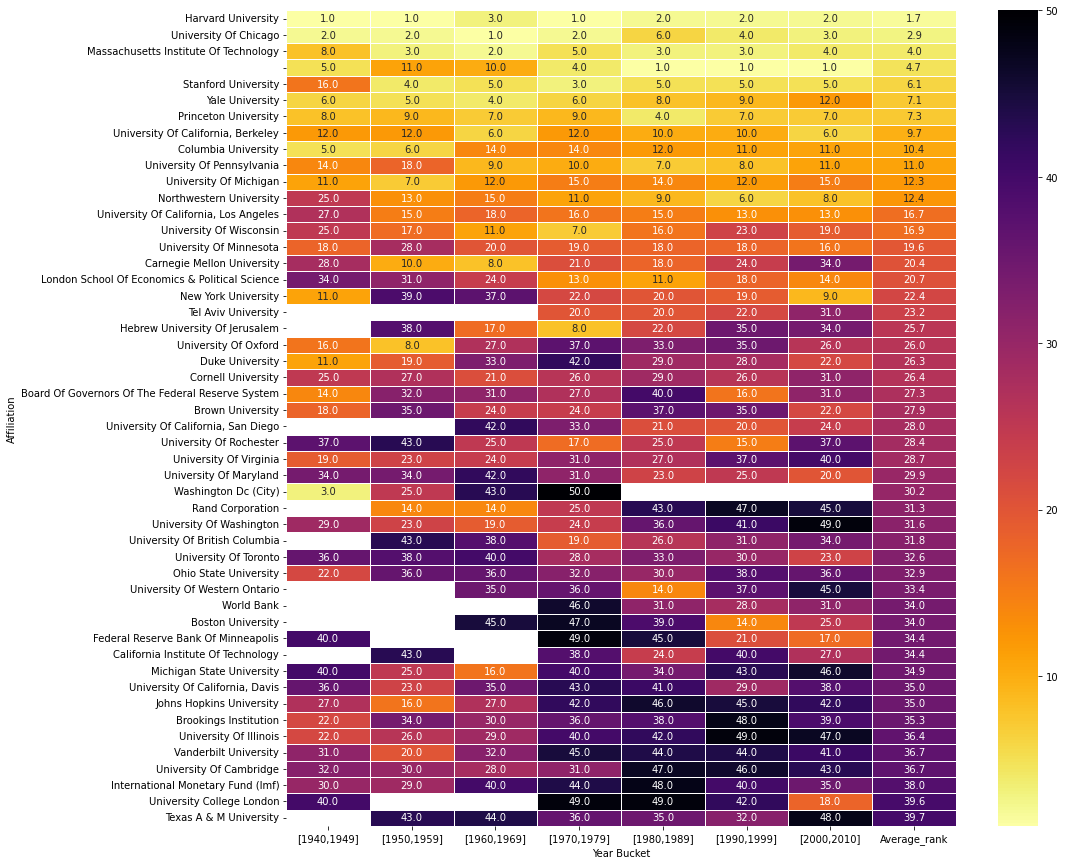

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
ranked['Rank'] = ranked['Rank'].astype(int)
#print(ranked.head())
invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='Rank')
invert_pivot['Average_rank'] = invert_pivot.mean(axis=1)
#print(invert_pivot)
#print(invert_pivot.head())
invert_pivot = invert_pivot.sort_values(by='Average_rank', ascending=True)
f, ax = plt.subplots(figsize=(15, 15))
cmap = plt.get_cmap('inferno_r')
sns.heatmap(invert_pivot, annot=True, fmt=".1f", cmap = cmap, linewidths=.5, ax=ax)

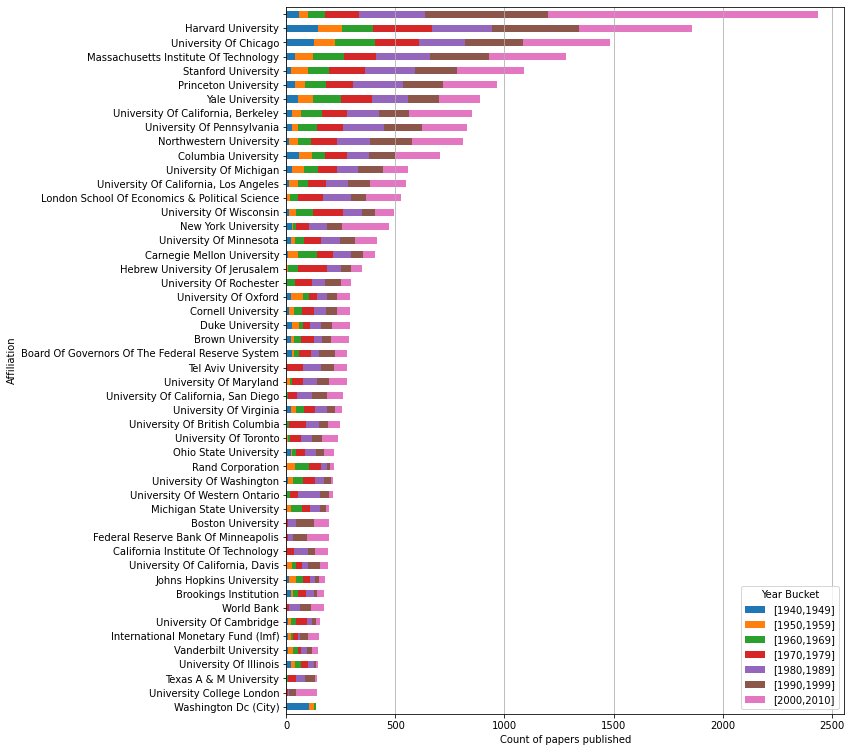

In [45]:
p = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')
#print(p)
p['sum_cols'] = p.sum(axis=1)
p = p.sort_values(by='sum_cols', ascending=True)
p = p.drop(['sum_cols'], axis=1)
ax = p.plot.barh(stacked=True, figsize=(10, 13))
#plt.xticks(np.arange(0, 375, step=25))
plt.xlabel('Count of papers published')
plt.grid(axis = 'x')
plt.get_cmap('inferno_r')
plt.show()
